In [10]:
import mne 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
from mne.datasets import eegbci

In [8]:
# 1. fetch file paths (run 1: resting state, run 4: motor imagery)
file_paths = eegbci.load_data(subjects=1, runs=[1, 4])

# 2. read resting state data into python
raw_rest = mne.io.read_raw_edf(file_paths[0], preload=True)

# 3. read active state data 
raw_active = mne.io.read_raw_edf(file_paths[1], preload=True)

print(f"resting data matrix shape: {raw_rest.get_data().shape}")
print(f"sampling freq: {raw_rest.info['sfreq']} Hz")

Extracting EDF parameters from /Users/pakachira/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Extracting EDF parameters from /Users/pakachira/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
resting data matrix shape: (64, 9760)
sampling freq: 160.0 Hz


In [9]:
import sys
sys.path.append('./src') # points to src directory
from preprocessing import butter_bandpass_filter 

# Filter resting-state signal matrix
filtered_rest = butter_bandpass_filter(
    data=raw_rest.get_data(),
    lowcut=8.0,
    highcut=30.0,
    fs=raw_rest.info['sfreq'],
    order=4
)

print(f"Raw Matrix Shape:      {raw_rest.get_data().shape}")
print(f"Filtered Matrix Shape: {filtered_rest.shape}")

Raw Matrix Shape:      (64, 9760)
Filtered Matrix Shape: (64, 9760)


In [11]:
# extract voltage array and time stamps
data, times = raw_rest.get_data(return_times=True)

# convert to dataframe (channels as columns, time points as rows)
df = pd.DataFrame(data.T, # transpose matrix for rows as time points and columns as channels
                  index=pd.Index(times, name="Time (s)"),
                  columns=raw_rest.ch_names)

# display first 5 rows of the dataframe
df.head()


,Fc5.,Fc3.,Fc1.,Fcz.,Fc2.,Fc4.,Fc6.,C5..,C3..,C1..,...,P8..,Po7.,Po3.,Poz.,Po4.,Po8.,O1..,Oz..,O2..,Iz..
Time (s),,,,,,,,,,,,,,,,,,,,,
0.00000,-0.000016,-0.000029,0.000002,0.000022,-0.000012,-0.000023,-0.000046,-0.000036,-0.000026,-0.000018,...,-0.000030,-0.000056,-0.000052,-0.000035,-0.000022,-0.000033,-0.000053,-0.000021,-0.000011,0.000015
0.00625,-0.000056,-0.000054,-0.000027,-0.000004,-0.000031,-0.000036,-0.000056,-0.000075,-0.000055,-0.000043,...,-0.000020,-0.000035,-0.000029,-0.000018,-0.000003,-0.000009,-0.000053,-0.000012,0.000001,0.000021
0.01250,-0.000055,-0.000055,-0.000029,-0.000005,-0.000029,-0.000034,-0.000052,-0.000053,-0.000042,-0.000035,...,-0.000020,-0.000023,-0.000012,-0.000006,0.000004,-0.000007,-0.000045,0.000002,0.000018,0.000035
0.01875,-0.000050,-0.000044,-0.000013,0.000013,-0.000016,-0.000025,-0.000045,-0.000044,-0.000021,-0.000011,...,-0.000016,-0.000012,0.000004,0.000014,0.000020,0.000007,-0.000029,0.000016,0.000035,0.000047
0.02500,-0.000036,-0.000028,0.000013,0.000042,0.000009,-0.000010,-0.000046,-0.000034,-0.000012,0.000008,...,-0.000009,-0.000007,0.000006,0.000020,0.000024,0.000006,-0.000013,0.000029,0.000040,0.000050


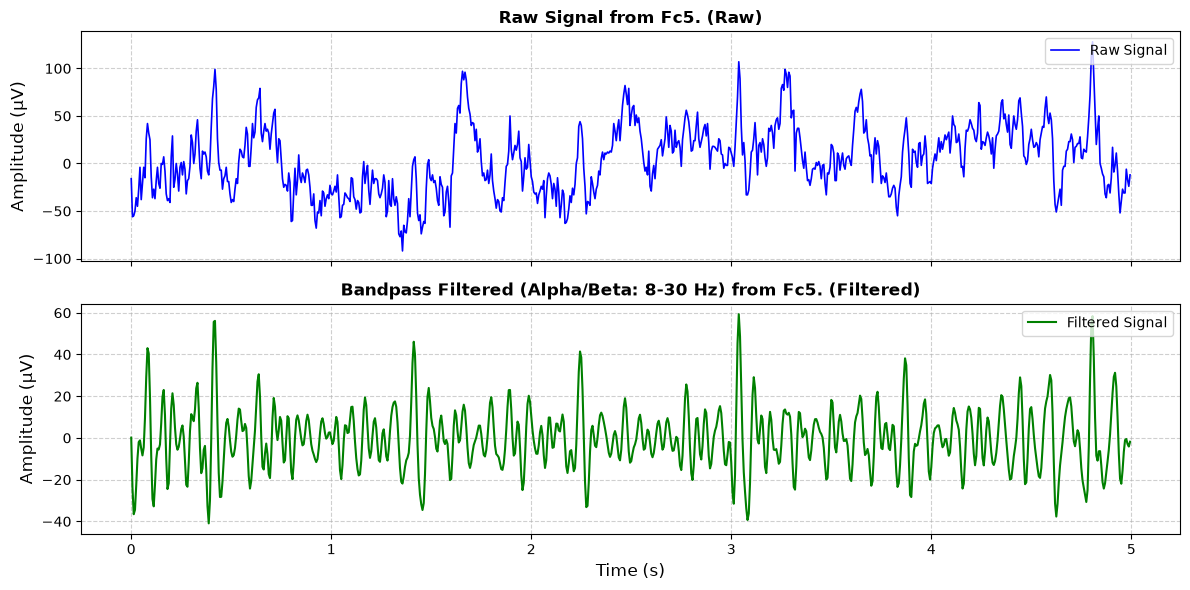

In [13]:
from visualization import plot_eeg_signal

# pick channel 0 (Fc5.)
channel_index = 0
channel_name = raw_rest.ch_names[channel_index]

times = raw_rest.times
raw_trace = raw_rest.get_data()[channel_index]
filtered_trace = filtered_rest[channel_index]

# Plot first 5 seconds
fig, axes = plot_eeg_signal(
    time=times,
    raw_signal=raw_trace,
    filtered_signal=filtered_trace,
    channel_name=channel_name,
    duration=5.0,
    fs=raw_rest.info['sfreq']
)

plt.show()